# Binary Classification Example with MerLin

The goal of this notebook is to serve as an example on how to use MerLin for a simple binary classification task. To do so, we will compare using a Variational Quantum Circuit (VQC) with using a quantum kernel approach for classification on Iris (2 classes only).

## 1. Import libraries

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import perceval as pcvl
import sklearn.svm
import torch
from tqdm import tqdm

import merlin
from merlin.datasets import iris

## Prepare dataset

For dataset, we will use 2-class Iris since it is a simple dataset with 4 features without being trivial. We specify 2-class here since the original Iris dataset has 3 classes, but we will only consider the first two.

In [21]:
train_features, train_labels, train_metadata = iris.get_data_train()
test_features, test_labels, test_metadata = iris.get_data_test()

assert len(train_features) == len(train_labels)
assert len(test_features) == len(test_labels)

# Filter training set to only keep first two labels
binary_train_features = []
binary_train_labels = []
for i in range(len(train_features)):
    if train_labels[i] > 1:
        continue
    else:
        binary_train_features.append(train_features[i])
        binary_train_labels.append(train_labels[i])

# Filter test set to only keep first two labels
binary_test_features = []
binary_test_labels = []
for i in range(len(test_features)):
    if test_labels[i] > 1:
        continue
    else:
        binary_test_features.append(test_features[i])
        binary_test_labels.append(test_labels[i])

# Convert data to PyTorch tensors
# 1-D labels for the fidelity kernel method
X_train = torch.FloatTensor(np.array(binary_train_features))
y_train_1D = torch.LongTensor(np.array(binary_train_labels))
X_test = torch.FloatTensor(np.array(binary_test_features))
y_test_1D = torch.LongTensor(np.array(binary_test_labels))

# Convert 1-dimensional labels to 2 dimensional one hot vectors
# For the VQC that uses Binary Cross Entropy Loss (BCELoss)
y_train_one_hot = torch.nn.functional.one_hot(y_train_1D, num_classes=2)
y_test_one_hot = torch.nn.functional.one_hot(y_test_1D, num_classes=2)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {len(torch.unique(y_train_1D))}")
print(f"All test labels: {y_test_1D}")
print(f"All test labels (one hot): \n{y_test_one_hot}")

# Convert one hot vectors from long to float
y_train = y_train_one_hot.float()
y_test = y_test_one_hot.float()

Training samples: 81
Test samples: 19
Features: 4
Classes: 2
All test labels: tensor([1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0])
All test labels (one hot): 
tensor([[0, 1],
        [0, 1],
        [1, 0],
        [0, 1],
        [1, 0],
        [1, 0],
        [0, 1],
        [1, 0],
        [0, 1],
        [1, 0],
        [1, 0],
        [0, 1],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0]])


### Visualization

Let's visualize the the first two features of our dataset.

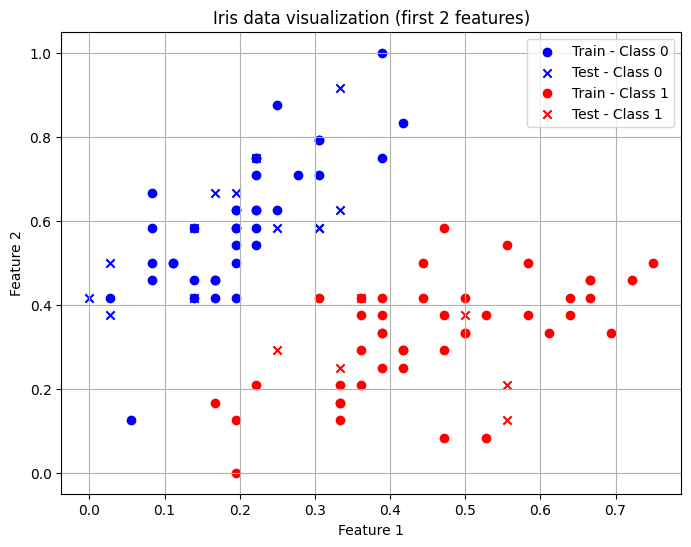

In [22]:
# Convert tensors to numpy
X_train_np = X_train.numpy()
y_train_np = y_train_1D.numpy()

X_test_np = X_test.numpy()
y_test_np = y_test_1D.numpy()

# Create masks for the two classes
train_class0 = y_train_np == 0
train_class1 = y_train_np == 1

test_class0 = y_test_np == 0
test_class1 = y_test_np == 1

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_np[train_class0, 0],
    X_train_np[train_class0, 1],
    marker="o",
    label="Train - Class 0",
    c="blue",
)
plt.scatter(
    X_test_np[test_class0, 0],
    X_test_np[test_class0, 1],
    marker="x",
    label="Test - Class 0",
    c="blue",
)
plt.scatter(
    X_train_np[train_class1, 0],
    X_train_np[train_class1, 1],
    marker="o",
    label="Train - Class 1",
    c="red",
)
plt.scatter(
    X_test_np[test_class1, 0],
    X_test_np[test_class1, 1],
    marker="x",
    label="Test - Class 1",
    c="red",
)

# Labels and legend
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Iris data visualization (first 2 features)")
plt.legend()
plt.grid(True)

plt.show()

## Define models

### VQC

To define the VQC, we must first define the photonic circuit we will use. One can use the `QuantumLayer.simple()` method for the highest-level entry point. For this tutorial however, we will use the `CircuitBuilder` which requires a bit more effort but offers more flexibility to the user.

### CircuitBuilder
We will use angle encoding so we need at least 4 modes to encode the 4 features on different modes. It is common practice to have d + 1 modes, where d is the number of features.

For the structure of our circuit, we will use the one proposed by [Gan et al.](https://arxiv.org/abs/2107.05224):

1. A trainable circuit block
2. A data encoding block (angle encoding) with one phase shifter encoder per mode
3. Another trainable circuit block

For the trainable circuit blocks, we will model the structure on the [Mach-Zehnder Interferometer](https://en.wikipedia.org/wiki/Mach%E2%80%93Zehnder_interferometer) (MZI) circuit structure.

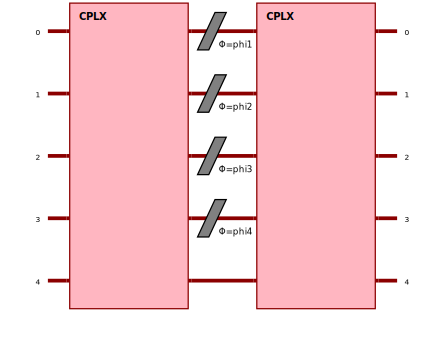

In [23]:
builder = merlin.CircuitBuilder(n_modes=5)
builder.add_entangling_layer(trainable=True, model="mzi", name="left")
builder.add_angle_encoding(modes=[0, 1, 2, 3], name="phi")
builder.add_entangling_layer(trainable=True, model="mzi", name="right")

# Visualize global circuit
pcvl.pdisplay(builder.to_pcvl_circuit())

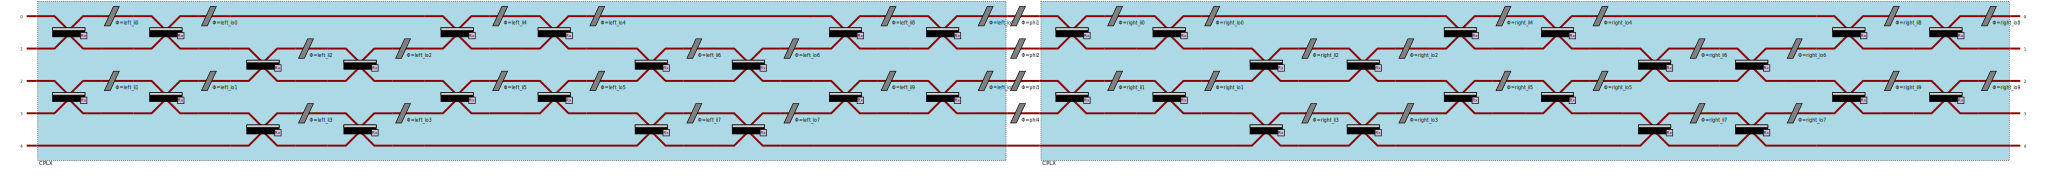

In [24]:
# For a detailed visualization of the entangling blocks
pcvl.pdisplay(builder.to_pcvl_circuit(), recursive=True)

### QuantumLayer

We must now define the quantum layer that will be our complete VQC. The number of photons controls the expressivity of the photonic circuit output. Note that it is good practice to have a number of photons inferior to the number of modes divided by two.

In [25]:
q_layer = merlin.QuantumLayer(
    builder=builder,
    n_photons=2,
    measurement_strategy=merlin.MeasurementStrategy.probs(
        computation_space=merlin.ComputationSpace.FOCK
    ),
)
# We have to map the number of outputs from the quantum layer to the number of classes (2)
# We use a grouping strategy from MerLin to do it
vqc = torch.nn.Sequential(q_layer, merlin.LexGrouping(q_layer.output_size, 2))

### Quantum Kernel Method (Fidelity Kernel)

The fidelity kernel encodes real inputs into a multi-Fock space, evaluates their overlaps and returns a similarity matrix.

We will use the `FidelityKernel.simple()` method from MerLin to define the quantum fidelity kernel with the highest-level of abstraction. A user with more experience could use the `FeatureMap` along with the `FidelityKernel` classes for more control.

In [26]:
fidelity_kernel = merlin.FidelityKernel.simple(
    input_size=4,
    n_modes=5,
    computation_space=merlin.ComputationSpace.FOCK,
)

## Training the models

The training for the two models considered is different so let's consider them separately once more.

### Training for the VQC

The training for this model is identical to how any other torch neural network model would be trained.

100%|██████████| 250/250 [00:01<00:00, 191.45it/s]


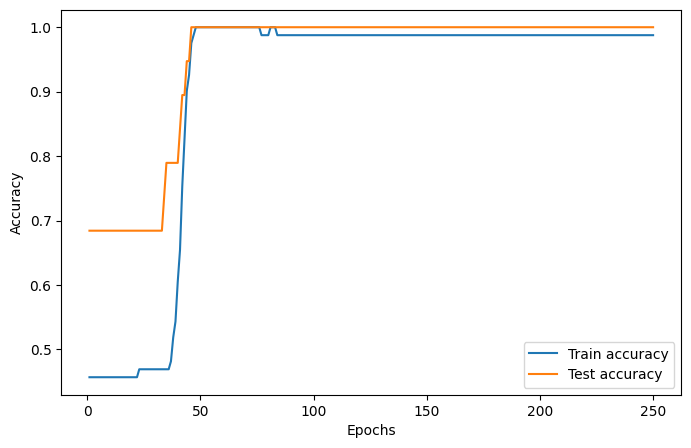

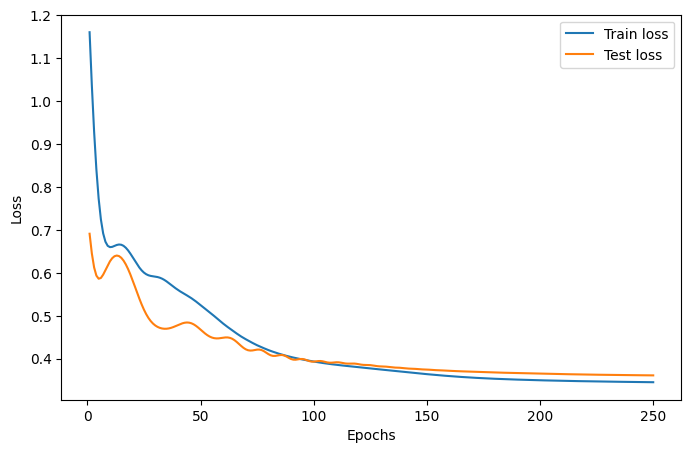

Final VQC test accuracy: 1.0


In [27]:
# Define most important hyperparameters
epochs = 250
lr = 0.02
optimizer = torch.optim.Adam(vqc.parameters(), lr=lr)
loss_fn = torch.nn.BCELoss()

# To store training metrics
train_accuracies = []
train_losses = []
test_accuracies = []
test_losses = []

for _ in tqdm(range(epochs)):
    vqc.train()
    optimizer.zero_grad()
    predictions = vqc(X_train)
    loss = loss_fn(predictions, y_train)
    loss.backward()
    optimizer.step()

    # Evaluate the model on the train set
    train_preds = predictions.argmax(dim=1)
    train_acc = (train_preds == y_train.argmax(dim=1)).float().mean().item()
    train_accuracies.append(train_acc)
    train_losses.append(loss.item())

    # Evaluate the model on the test set
    vqc.eval()
    predictions = vqc(X_test)
    test_preds = predictions.argmax(dim=1)
    test_acc = (test_preds == y_test.argmax(dim=1)).float().mean().item()
    test_accuracies.append(test_acc)
    with torch.no_grad():
        loss = loss_fn(predictions, y_test)
        test_losses.append(loss.item())


epoch_range = range(1, epochs + 1)

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, train_accuracies, label="Train accuracy")
plt.plot(epoch_range, test_accuracies, label="Test accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, train_losses, label="Train loss")
plt.plot(epoch_range, test_losses, label="Test loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

print(f"Final VQC test accuracy: {test_accuracies[-1]}")

### Training for the quantum kernel method

The training for this model is similar to the training of other kernel methods. We will use the SVC class from scikit-learn because it accepts pre-computed kernels.

In [28]:
svc = sklearn.svm.SVC(kernel="precomputed")

K_train = fidelity_kernel(X_train)
K_test = fidelity_kernel(X_test, X_train)
print("Train kernel matrix shape:", K_train.shape)
print("Test kernel matrix shape:", K_test.shape)

print("SVC training started")
svc.fit(K_train.detach().numpy(), y_train_1D.detach().numpy())
print("SVC training ended")
test_accuracy = svc.score(K_test.detach().numpy(), y_test_1D.detach().numpy())
print(f"Final quantum fidelity kernel test accuracy: {test_accuracy}")

Train kernel matrix shape: torch.Size([81, 81])
Test kernel matrix shape: torch.Size([19, 81])
SVC training started
SVC training ended
Final quantum fidelity kernel test accuracy: 1.0


## Conclusion

In the end, we see that both approaches manage to perfectly classify this dataset. You can choose to use which methodology you prefer but it usually is good practice to consider both of these large families of models. 

For more information on how to use the ideal VQC, look at the [QuantumLayer Essentials page](https://merlinquantum.ai/user_guide/layer.html).

For more information on how to use the ideal quantum fidelity kernel, look at the [Photonic Kernel Methods page](https://merlinquantum.ai/user_guide/kernels.html).